In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from stark.pp import stark_process
from stark.pp import recommend_by_leiden
output_dir = "/Users/ckw/warehouse/metacell/stark/test_output"
data_dir = "/Users/ckw/warehouse/metacell/data/test_700_snm3c"
genome_reference_path = "/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes"
chrom_list = [f"chr{i}" for i in range(1, 23)] 
resolution = [1000000,500000,100000]
# stark_process(output_dir,
#                 data_dir,
#                 genome_reference_path,
#                 chrom_list,
                
#                 resolution)

print("This is v1/code.py")

This is v1/code.py


In [2]:
depth_df = pd.read_csv(output_dir + "/depth.txt",header=None)
view3_pca = np.load('/Users/ckw/warehouse/metacell/stark/test_output/pca_vec_1000000.npy')
view2_pca = np.load('/Users/ckw/warehouse/metacell/stark/test_output/pca_vec_500000.npy')
view1_pca = np.load('/Users/ckw/warehouse/metacell/stark/test_output/pca_vec_100000.npy')
view3_umap = np.load('/Users/ckw/warehouse/metacell/stark/test_output/umap_vec_1000000.npy')
view2_umap = np.load('/Users/ckw/warehouse/metacell/stark/test_output/umap_vec_500000.npy')
view1_umap = np.load('/Users/ckw/warehouse/metacell/stark/test_output/umap_vec_100000.npy')
print(view1_pca.shape, view2_pca.shape, view3_pca.shape)

(700, 84) (700, 114) (700, 123)


In [3]:
lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])

In [4]:
# 为每个lb创建颜色
import seaborn as sns
unique_labels = list(set(lb))
palette = sns.color_palette("husl", len(unique_labels))
label_color_map = {label: palette[i] for i, label in enumerate(unique_labels)}
colors = [label_color_map[label] for label in lb]

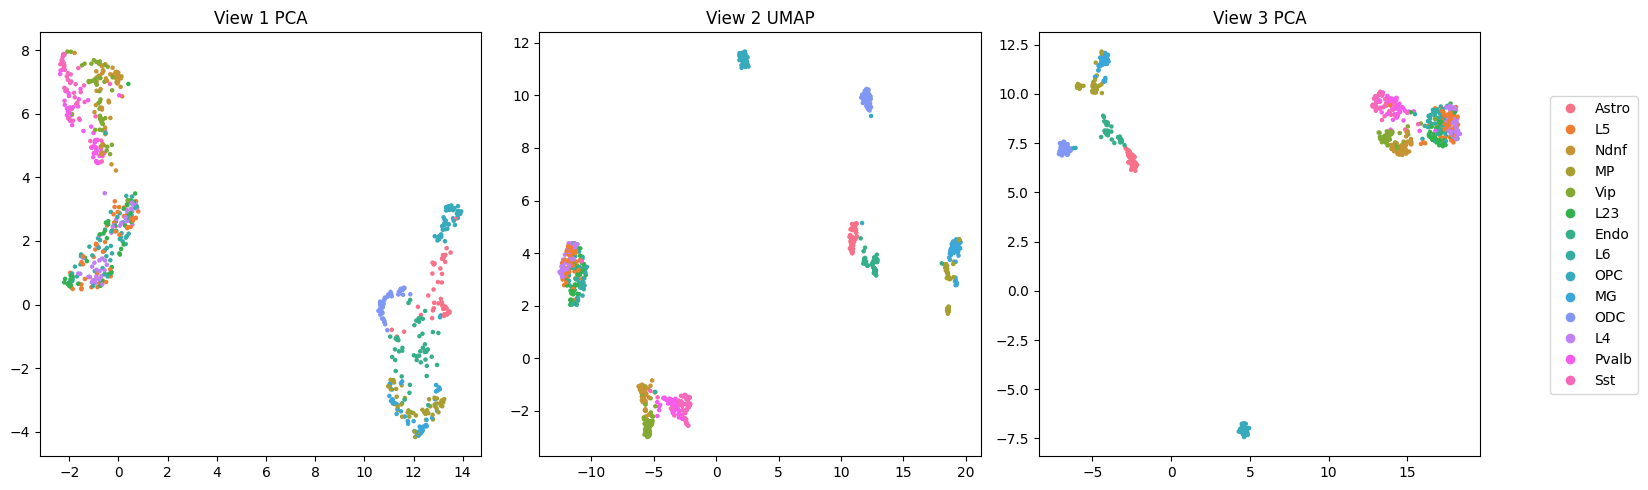

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].scatter(view1_umap[:,0], view1_umap[:,1], c=colors, s=5)
ax[0].set_title('View 1 PCA')
ax[1].scatter(view2_umap[:,0], view2_umap[:,1], c=colors, s=5)
ax[1].set_title('View 2 UMAP')
ax[2].scatter(view3_umap[:,0], view3_umap[:,1], c=colors, s=5)
ax[2].set_title('View 3 PCA')

# 添加总的legend
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=label_color_map[label], markersize=8, label=label) 
           for label in unique_labels]
fig.legend(handles=handles, loc='center right', bbox_to_anchor=(1.1, 0.5))

plt.tight_layout()
plt.show()

mean_depth:0.11M


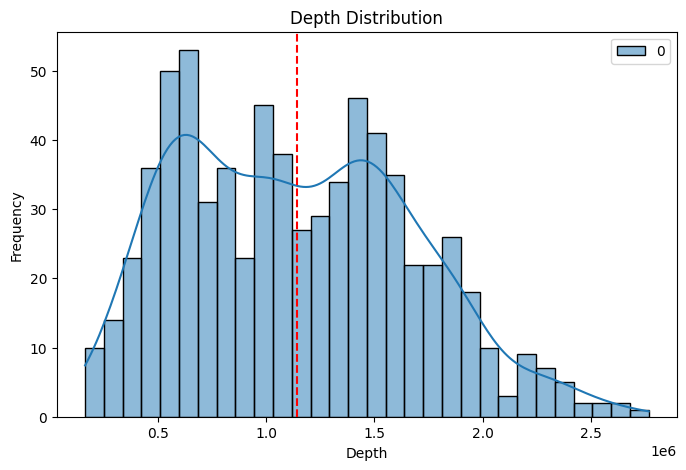

In [6]:
# depth的分布
plt.figure(figsize=(8, 5))
mean_depth = depth_df[0].mean()
print(f'mean_depth:{mean_depth/1e7:.2f}M')
sns.histplot(depth_df, bins=30, kde=True)
plt.axvline(mean_depth, color='red', linestyle='--', label=f'Mean Depth: {mean_depth:.2f}')
plt.title('Depth Distribution')
plt.xlabel('Depth')
plt.ylabel('Frequency')
plt.show()
# recommended metacell number



正在构建 AnnData 并计算近邻图 (n_neighbors=15)...


/Users/ckw/warehouse/metacell/stark/stark/pp/rec_num.py:65: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(X=features)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


正在执行 Leiden 聚类 (resolution=2.0)...
✅ 聚类完成，共发现 15 个聚类簇。

💡 基于 Leiden 聚类的推荐结果: 最终总 n_metacells 范围 = [22, 39]


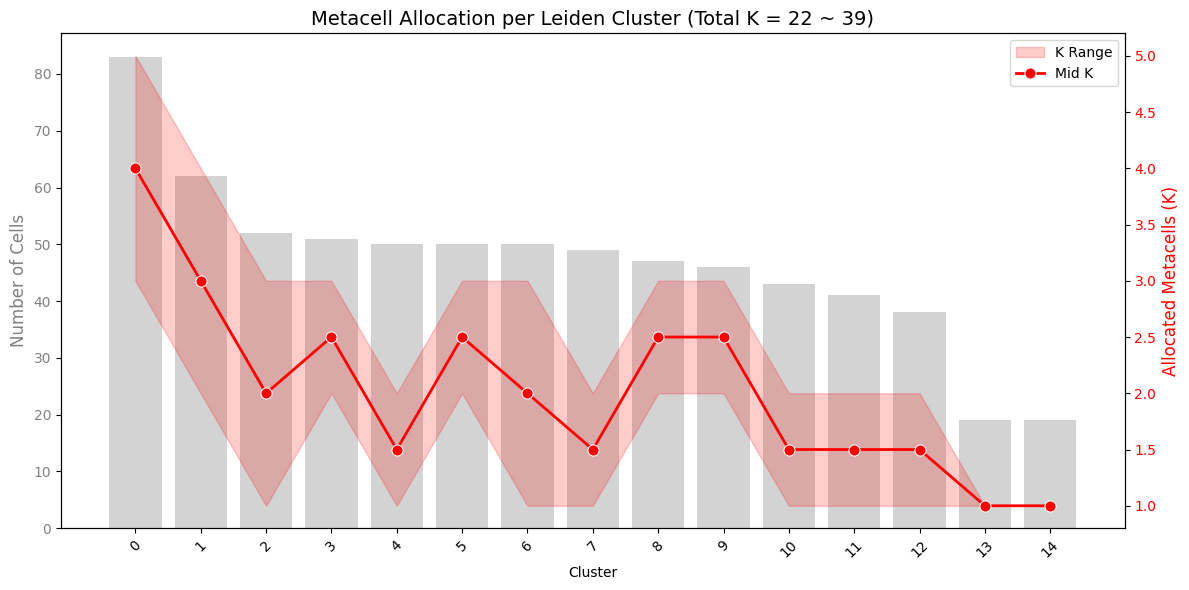

推荐的 Metacell 数量范围: 22 到 39


In [7]:
# 2. 提取深度为一维 numpy 数组 (假设深度在第 0 列)
depth_array = depth_df[0].values 

min_k, max_k = recommend_by_leiden(
    depth_array=depth_array,
    features=view3_pca,
    target_depth_min=20*1e6,  # 下限 500M
    target_depth_max=40*1e6,  # 上限 800M
    resolution=2.0,
    n_neighbors=15
)

print(f"推荐的 Metacell 数量范围: {min_k} 到 {max_k}")
# 然后你可以取中间值、或者针对范围内的几个值分别训练对比

In [8]:
# 核心：直接导入我们重构好的多视图模型
from stark import MultiViewSEACells

In [9]:

model = MultiViewSEACells(
    n_metacells=30,          # 目标 MetaCell 数量
    lambda_sparse=0.0000,     # 稀疏惩罚
    lambda_balance=0.01,       # 平衡惩罚
    lambda_consistency=0.001, # 一致性惩罚
    max_iter=100,
    
    # --- scHi-C 深度优化参数 ---
    min_size_threshold=0.002, # 重生阈值: 0.2%。如果 MetaCell 包含细胞数少于总数的 0.2%，将被判定为无效。
    respawn_interval=10,       # 检查频率: 每 10 次迭代检查并执行一次“重生”。
    split_metric='pca'
)

# model.compute_kernels([view1_pca[:,1:], view2_pca[:,1:], view3_pca[:,1:]],save_dir=None)
from sklearn.preprocessing import normalize

model.compute_kernels([view1_pca,view2_pca,view3_pca],save_dir=None)






步骤1: 构建核矩阵 (Cache Dir: None)
  [View 0] 开始内部计算 RBF 核矩阵 (Input: (700, 84))...


/Users/ckw/warehouse/metacell/stark/stark/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)
/Users/ckw/opt/anaconda3/envs/ckw/lib/python3.10/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0
  [View 1] 开始内部计算 RBF 核矩阵 (Input: (700, 114))...


/Users/ckw/warehouse/metacell/stark/stark/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)
/Users/ckw/opt/anaconda3/envs/ckw/lib/python3.10/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0
  [View 2] 开始内部计算 RBF 核矩阵 (Input: (700, 123))...


/Users/ckw/warehouse/metacell/stark/stark/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)
/Users/ckw/opt/anaconda3/envs/ckw/lib/python3.10/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


  -> 核矩阵就绪: Shape=(700, 700), Sparsity=1.0



步骤2: 参数初始化 (Data: kernel, Method: Micro-Clustering)
  正在合并核矩阵用于初始化...
  执行 MiniBatchKMeans (k=30)...
  最终选中 30 个 Waypoints


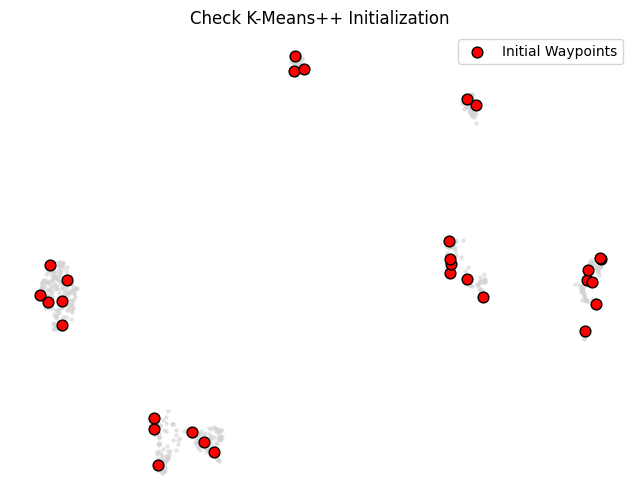

In [10]:
# ==========================================
# 4. 初始化 (使用 K-Means++ 避免空白区)
# ==========================================
# init_method='kmeans++': 
#    - 优先选择数据密度高的区域
#    - 避免 MaxMin 采样容易选到边缘 Outlier 的问题
#    - 有效缓解初始 MetaCell 落在两个 Cluster 中间的问题
model.initialize(seed=32, data_type='kernel', n_micro_clusters=30)
# ==========================================
# 5. 可视化初始化结果
# ==========================================
# 这一步是为了确认初始点没有落在“空白处”
model.plot_initialization(view2_umap, title="Check K-Means++ Initialization")

In [11]:
model.fit(n_threads=10)


步骤4: 联合优化 (Split Metric: pca)
Iter   0 | Loss: 1450.8095 | Size Range: 16.2-27.2
Iter  10 | Loss: 1329.2302 | Size Range: 16.2-28.3
Iter  20 | Loss: 1327.7801 | Size Range: 15.8-28.9
Iter  30 | Loss: 1317.7470 | Size Range: 15.4-28.0
Iter  40 | Loss: 1315.2121 | Size Range: 13.9-28.5
Iter  50 | Loss: 1308.0581 | Size Range: 15.8-30.5
Iter  60 | Loss: 1301.4678 | Size Range: 16.3-29.4
Iter  70 | Loss: 1306.1933 | Size Range: 16.0-30.1
Iter  80 | Loss: 1301.0752 | Size Range: 16.6-29.8
Iter  90 | Loss: 1293.1669 | Size Range: 16.1-30.1

优化完成


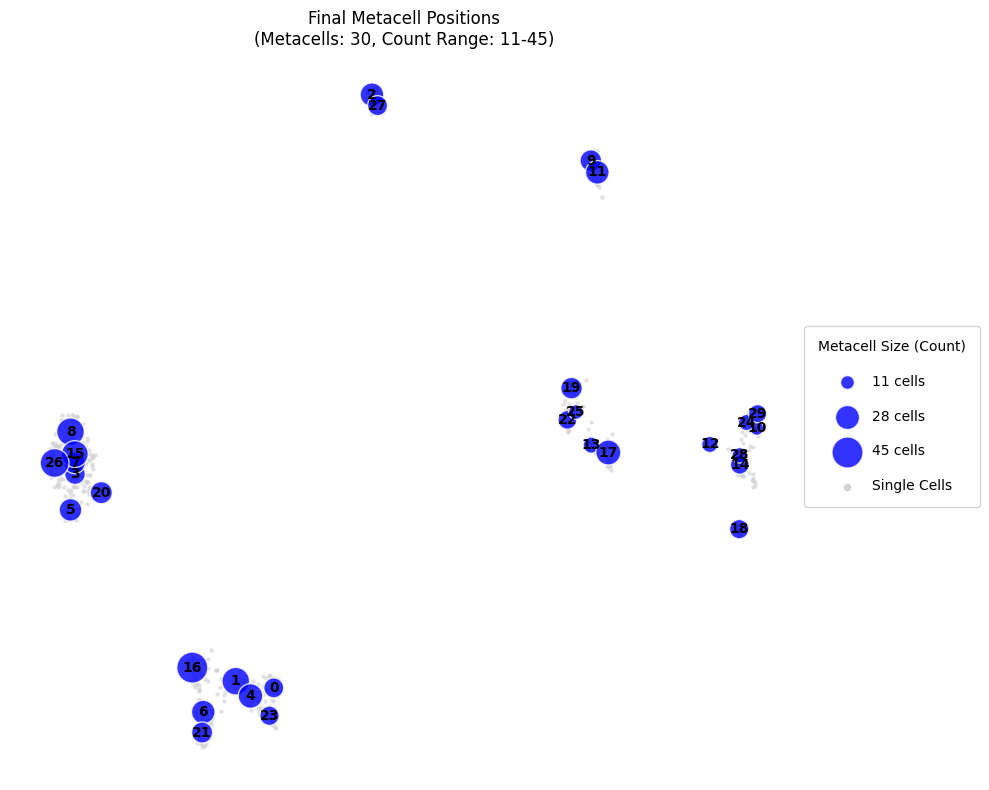

In [12]:
model.plot_metacells(view2_umap, title="Final Metacell Positions",show_idx=True,max_size=500,min_size=100)

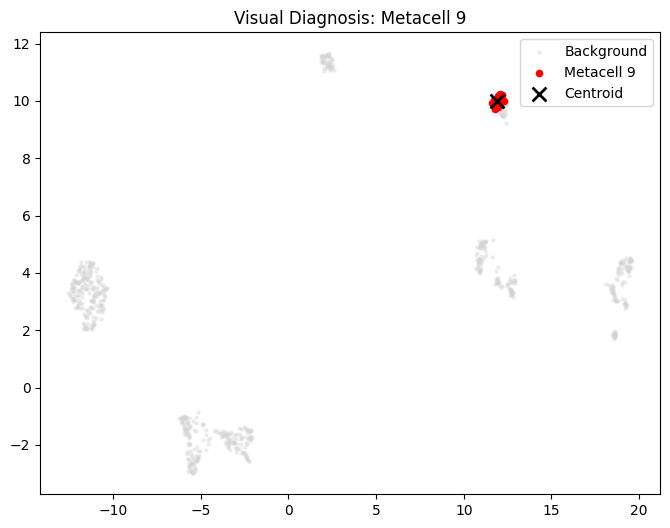

In [13]:
idx = 9

model.plot_specific_metacell( view2_umap,idx)

In [14]:
# 1. 后端静默计算（仅运算、缓存，屏幕干净不弹图）
purity_df = model.calculate_metrics(lb)

# 2. 如果你想看关键数值打分
metrics = model.get_metrics_summary()



正在计算评估指标...
✅ 指标计算完成！(发现 14 种细胞类型)
----------------------------------------
简单平均纯度 (Mean Purity)  : 0.7853
模型准确率 (Accuracy)      : 0.7629
全局加权分 (Global Score)  : 0.5903
----------------------------------------


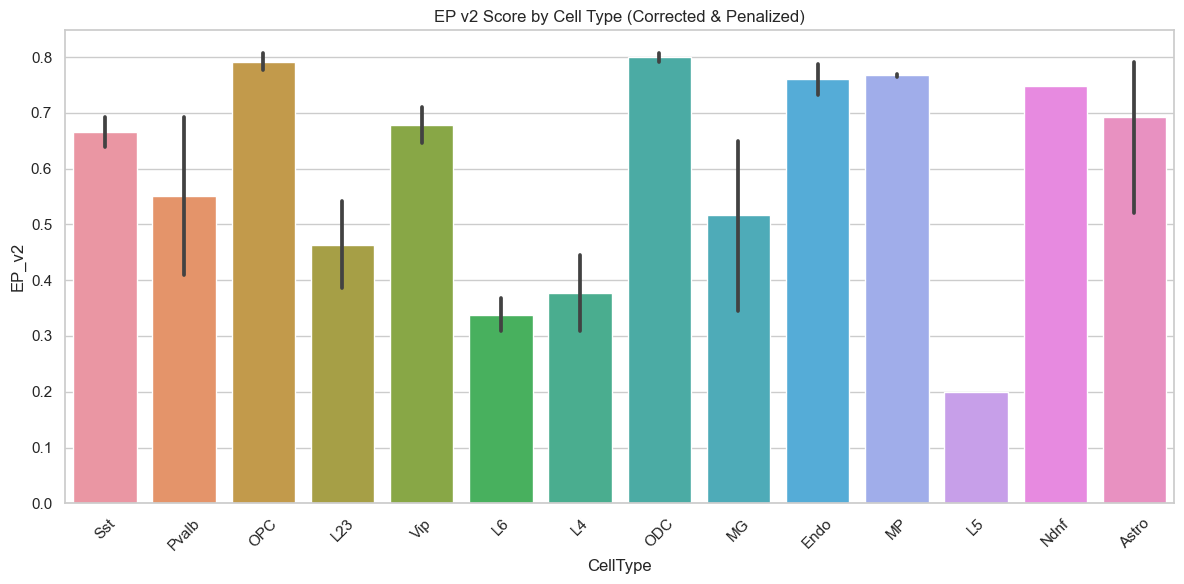

In [15]:

# 3. 按您的需求随心绘制单一图表
model.plot_ep_score()                      # 想看细胞类型的惩罚纯度评分柱状图时


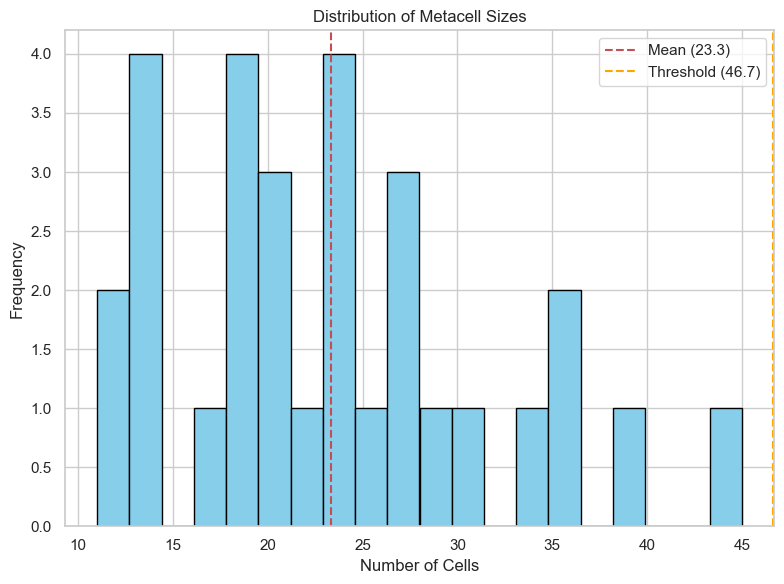

In [16]:
model.plot_metacell_sizes()                # 想诊断一下大小分布时


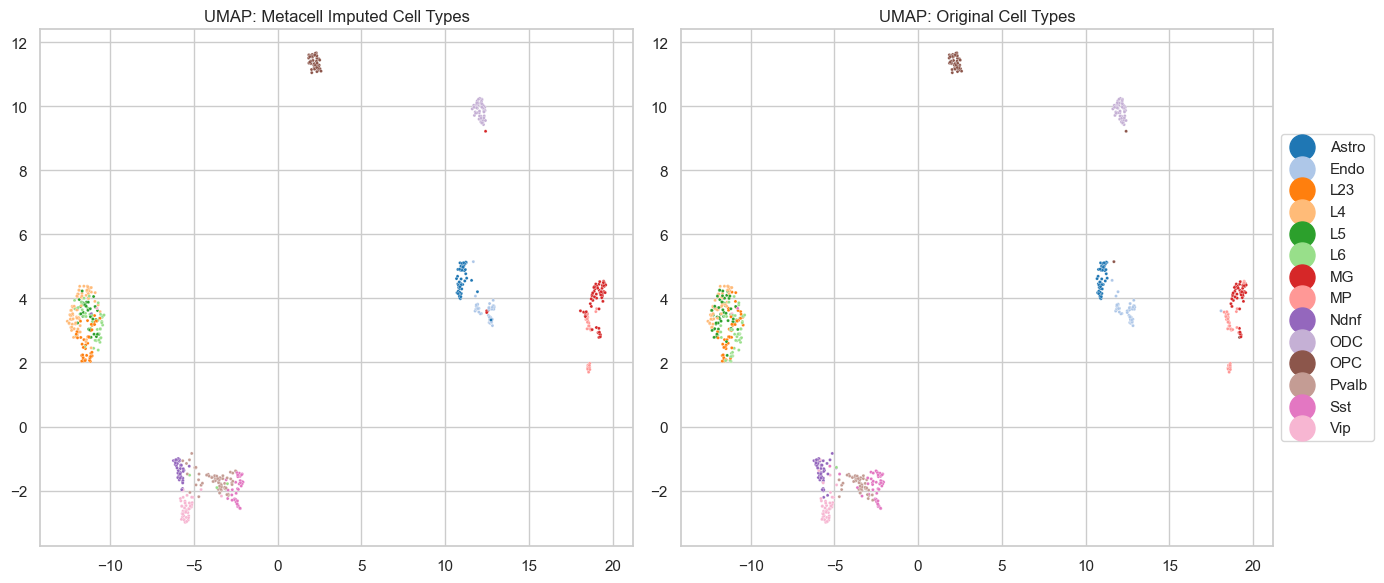

In [17]:
model.plot_umap_comparison(view2_umap)     # 想直观对比二维映射时